### 고양이 수염 스티커 만들기

In [1]:
#패키지 설치 
!pip install cmake
!pip install opencv-python
!conda install -y dlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.5/29.5 MB 36.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 42.4 MB/s eta 0:00:0000:0100:01
Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - dlib


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.6.17  |       hbd8a1cb_0         126 KB  conda-forge
    certifi-2026.6.17          |     pyhd8ed1ab_0         131 KB  conda-forge
    dlib-20.0.0                |cpu_py312hb8e531a_0         3.3 MB  conda-forge
    openssl-3.6.3              |       h35e630c_0         3.0 MB  conda-forge
    -----

In [2]:
# 필요한 패키지 import 하기
import os 
import cv2 
import matplotlib.pyplot as plt 
import numpy as np 
import dlib 
print("🌫🛸")

🌫🛸


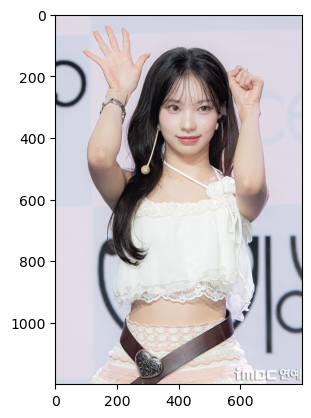

In [3]:
# 이미지 경로 지정 및 확인
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/images/image.png') 
img_bgr = cv2.imread(my_image_path)   
img_show = img_bgr.copy()      
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) # 이미지 실제 출력하기 위해 이미지를 올려줌 (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 합니다.)
plt.show() # 이미지 실제 출력

In [4]:
# detector를 선언합니다
detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환
print("🌫🛸")

🌫🛸


In [5]:
# detector_hog를 이용해서 얼굴의 bounding box를 추출
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)
print("🌫🛸")

🌫🛸


rectangles[[(345, 263) (531, 449)]]


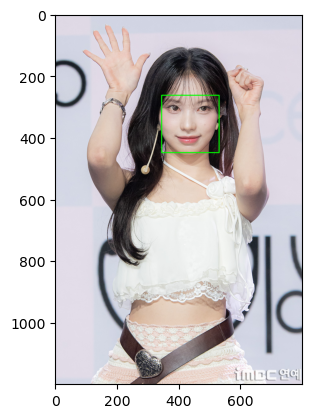

In [6]:
# 찾은 얼굴 영역 박스 리스트

print(dlib_rects)

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

In [7]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat.bz2 ~/work/camera_sticker/models
!cd ~/work/camera_sticker && bzip2 -d ./models/shape_predictor_68_face_landmarks.dat.bz2

--2026-06-22 07:45:54--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-06-22 07:45:55--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  9.22MB/s    in 8.3s    

2026-06-22 07:46:04 (7.34 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

bzip2: Output file ./models/shape_predictor_68_face_landmarks.dat already exists.


In [8]:
model_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models/shape_predictor_68_face_landmarks.dat')
    # 저장한 landmark 모델의 주소를 model_path 변수에 저장
landmark_predictor = dlib.shape_predictor(model_path)
    # dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
    # landmark_predictor는 RGB이미지와 dlib.rectangle를 입력 받고 dlib.full_object_detection를 반환
    # dlib.rectangle: 내부를 예측하는 박스
    # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체의 위치를 나타냄
print("🌫🛸")

🌫🛸


In [9]:
list_landmarks = []
    # 랜드마크의 위치를 저장할 list 생성

# 얼굴 영역 박스 마다 face landmark를 찾아냅니다
# face landmark 좌표를 저장해둡니다
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
        # 모든 landmark의 위치정보를 points 변수에 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
        # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_landmarks.append(list_points)
        # list_landmarks에 랜드마크 리스트를 저장

print(len(list_landmarks[0]))
    # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고
    # 각 원소는 68개의 랜드마크 위치가 나열된 list
    # list_landmarks의 원소가 1개이므로 list_landmarks[1]을 호출하면 IndexError가 발생

68


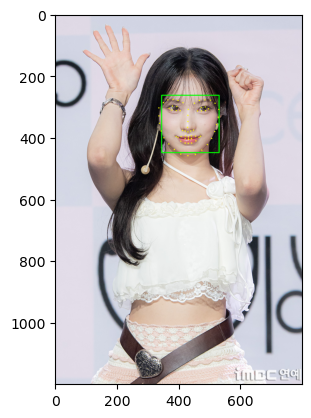

In [10]:
# list_landmarks의 원소가 1개이므로 아래 반복문은 한번만 실행됨
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)
            # cv2.circle: OpenCV의 원을 그리는 함수
            # img_show 이미지 위 각각의 point에
            # 크기가 2이고 (0, 255, 255)색으로 내부가 채워진(-1) 원을 그림
            # (마지막 인수가 자연수라면 그만큼의 두께의 선으로 원이 그려짐)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
    # RGB 이미지로 전환
plt.imshow(img_show_rgb)
    # 이미지를 준비
plt.show()
    # 이미지를 출력

In [11]:
# 스티커 이미지 경로 설정 및 로드
sticker_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/images/cat.png')
# 투명도 유지를 위해 cv2.IMREAD_UNCHANGED 사용 권장
img_sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED) 

# 스티커 크기 조정 (예시로 187x187로 설정, 상황에 맞게 조절)
img_sticker = cv2.resize(img_sticker, (187, 187)) 
print(img_sticker.shape)

(187, 187, 4)


In [12]:
# 코 끝 좌표(30번) 기준점으로 스티커 배치
x = list_landmarks[0][30][0]
y = list_landmarks[0][30][1]

w = img_sticker.shape[1]
h = img_sticker.shape[0]

refined_x = x - w // 2
refined_y = y - h // 2

print(f"좌표: ({refined_x}, {refined_y})")

좌표: (336, 274)


In [13]:

refined_x = x - w // 2 
refined_y = y - h 
print (f'(x,y) : ({refined_x},{refined_y})') 

(x,y) : (336,180)


In [14]:
w = img_sticker.shape[1]
h = img_sticker.shape[0]

#코 끝을 중심으로 좌표 이동
refined_x = x - w // 2
refined_y = y - h // 2

# 이미지 경계 예외 처리
if refined_y < 0:
    # 스티커가 잘릴 경우를 대비해 스티커 자체를 슬라이싱
    img_sticker = img_sticker[-refined_y:, :]
    refined_y = 0
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0

print(f'(refined_x, refined_y) : ({refined_x}, {refined_y})')

(refined_x, refined_y) : (336, 274)


In [15]:
# sticker_area: 스티커가 들어갈 원본 이미지 영역
sticker_area = img_show[refined_y:refined_y + img_sticker.shape[0], refined_x:refined_x + img_sticker.shape[1]]

# 알파 채널이 있는 경우 (img_sticker가 4채널일 때)
if img_sticker.shape[2] == 4:
    # 0~1 사이로 정규화
    alpha = img_sticker[:, :, 3] / 255.0
    
    # 3채널(BGR) 각각에 대해 합성 공식 적용
    for i in range(3):
        img_show[refined_y:refined_y + img_sticker.shape[0], refined_x:refined_x + img_sticker.shape[1], i] = \
            (1 - alpha) * sticker_area[:, :, i] + alpha * img_sticker[:, :, i]
else:
    # 알파 채널이 없다면 기존 방식(단, 배경색이 0인 경우만 가능)
    img_show[refined_y:refined_y + img_sticker.shape[0], refined_x:refined_x + img_sticker.shape[1]] = \
        np.where(img_sticker == 0, sticker_area, img_sticker)

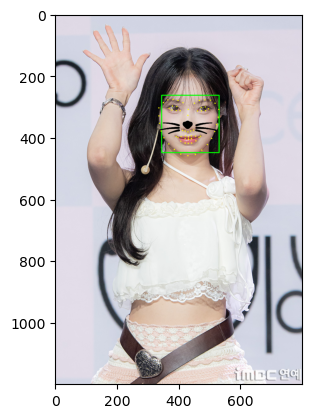

In [16]:
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

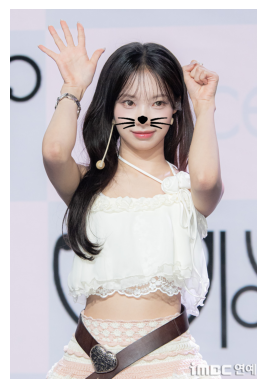

In [17]:
# 0. 원본 이미지(스티커가 없는 상태)를 다시 로드하거나 복사본 사용
img_result = img_bgr.copy() # 원본 이미지(img_bgr)를 사용하여 새로 시작

# 1. 스티커에서 컬러(BGR)와 알파 채널 분리
sticker_img = img_sticker[:, :, :3]
alpha = img_sticker[:, :, 3:] / 255.0

# 2. 합성 영역(sticker_area) 추출 (img_result 대상)
sticker_area = img_result[refined_y:refined_y + img_sticker.shape[0], refined_x:refined_x + img_sticker.shape[1]]

# 3. 알파 블렌딩 공식 적용
img_result[refined_y:refined_y + img_sticker.shape[0], refined_x:refined_x + img_sticker.shape[1]] = \
    (1 - alpha) * sticker_area + alpha * sticker_img

# 4. 결과 출력 (녹색 선과 점이 없는 깨끗한 이미지)
plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
plt.axis('off') # 축도 제거하여 깔끔하게 표시
plt.show()

#### 테스트1) 얼굴 각도가 틀어진 사진에 스티커 붙이기, 스티커 위치 재조정  
##### 수정방향1) 얼굴 각도를 계산하여 스티커를 회전시킨 뒤, 얼굴의 코 끝 위치(30번 랜드마크)에 합성  
##### 수정방향2) 스티커가 위치하는 좌표를 랜드마크 33번과 51번 사이에 두어 더 자연스럽게 배치될 수 있도록 수정 


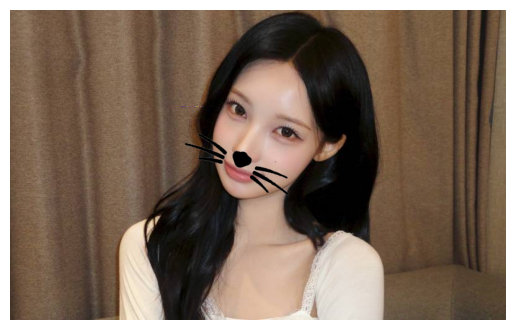

In [39]:
import cv2
import dlib
import numpy as np
import os
import matplotlib.pyplot as plt

# 1. 경로 설정 
img_bgr = cv2.imread(os.path.join(image_dir, 'image1.png'))
sticker_img = cv2.imread(os.path.join(image_dir, 'cat.png'), cv2.IMREAD_UNCHANGED)

detector_hog = dlib.get_frontal_face_detector()
landmark_predictor = dlib.shape_predictor(model_path)

# 2. 얼굴 검출 
dets = detector_hog(img_bgr, 1)
if len(dets) > 0:
    d = dets[0]
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    landmark = landmark_predictor(gray, d)
    list_landmarks = list(map(lambda p: (p.x, p.y), landmark.parts()))

# 3. 얼굴 기울기 계산 (눈 사이의 각도)
# 왼쪽 눈(36번)과 오른쪽 눈(45번) 좌표 사용
    eye_delta_x = list_landmarks[45][0] - list_landmarks[36][0]
    eye_delta_y = list_landmarks[45][1] - list_landmarks[36][1]
    angle = np.degrees(np.arctan2(eye_delta_y, eye_delta_x))

# 4. 스티커 준비 및 회전 
    w = d.width()
    sticker_resized = cv2.resize(sticker_img, (w, w))
    
    # 계산된 angle 값 앞에 마이너스(-)를 붙여 반대 방향으로 회전시킵니다.
    rotated_angle = -angle 
    
    # 스티커 회전 (중심축 유지)
    (h_s, w_s) = sticker_resized.shape[:2]
    center = (w_s // 2, h_s // 2)
    M = cv2.getRotationMatrix2D(center, rotated_angle, 1.0)
    sticker_rotated = cv2.warpAffine(sticker_resized, M, (w_s, h_s), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_TRANSPARENT)

# 5. 합성 (인중 위치로 중앙 배치 : 33번과 51번 사이)
    center_x = (list_landmarks[33][0] + list_landmarks[51][0]) // 2
    center_y = (list_landmarks[33][1] + list_landmarks[51][1]) // 2
    
    # 스티커 중심이 계산된 center 좌표에 오도록 설정
    # refined_x, refined_y는 ROI 영역의 좌측 상단 기준점이므로 w // 2를 빼줍니다.
    refined_x = center_x - w // 2
    refined_y = center_y - w // 2   
    alpha = sticker_rotated[:, :, 3] / 255.0
    sticker_rgb = sticker_rotated[:, :, :3]
    
    y1, y2 = max(0, refined_y), min(img_bgr.shape[0], refined_y + w)
    x1, x2 = max(0, refined_x), min(img_bgr.shape[1], refined_x + w)
    
    roi = img_bgr[y1:y2, x1:x2]
    for c in range(0, 3):
        mask = alpha[0:y2-y1, 0:x2-x1]
        img_bgr[y1:y2, x1:x2, c] = (1 - mask) * roi[:, :, c] + mask * sticker_rgb[0:y2-y1, 0:x2-x1, c]

    # 결과 출력
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
else:
    print("얼굴을 찾을 수 없습니다.")

#### 회고  
##### - 일상에서 자주 사용하는 스티커 핪성이 어떤 방식으로 이루어지는지 실습을 통해 알 수 있었습니다.  
##### - 랜드마크를 추출하는 모델의 경우, 이미지가 기울어져 있는 경우 정상적으로 좌표를 확인하기 어려운 문제가 있기에 이 부분을 해결하는 작업을 진행하였다. 다른 모델을 사용하는 방법 등이 있었는데 이 부분은 확인을 하지 못했기에 제한적인 조건에서 해결 방법을 찾게 되었습니다.  
##### - AI의 도움을 많이 받았기 때문에 아직 자립적으로 코딩을 하지는 못하였기에 이 부분은 계속 마음에 걸립니다.  